## 1. Install and import

In [1]:
!pip install kagglehub
import os
import random
import numpy as np
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, random_split, WeightedRandomSampler
from torchvision import datasets, transforms, models


Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip


## 2. Download dataset

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("debeshjha1/surgical-instrument-classification")

print("Downloaded dataset path:", path)


/Users/abroadhub/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Downloaded dataset path: /Users/abroadhub/.cache/kagglehub/datasets/debeshjha1/surgical-instrument-classification/versions/1


## 3. Check folder structure
*Run this to see where the class folders are:*

In [3]:
root_path = Path(path)

for item in root_path.iterdir():
    print(item)

/Users/abroadhub/.cache/kagglehub/datasets/debeshjha1/surgical-instrument-classification/versions/1/Instrument Data


In [4]:
from pathlib import Path

data_dir = Path(path) / "Instrument Data"

print(data_dir)

/Users/abroadhub/.cache/kagglehub/datasets/debeshjha1/surgical-instrument-classification/versions/1/Instrument Data


In [5]:
for item in data_dir.iterdir():
    print(item.name)

Clip
Chain
No Instrument
White Tube
Doubt
Hook
Hold


## 4. Set device and seed

In [6]:
device = torch.device( "mps" if torch.backends.mps.is_available() else "cpu")
print(device)

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

mps


## 5. Define transforms

*Train set gets augmentation.* </b>
*Validation/test get only resize + tensor.*

In [7]:
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224, scale=(0.85, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

## 6. Load full dataset first

In [8]:
full_dataset = datasets.ImageFolder(root=data_dir)

print("Classes:", full_dataset.classes)
print("Class to index:", full_dataset.class_to_idx)
print("Total images:", len(full_dataset))

Classes: ['Chain', 'Clip', 'Doubt', 'Hold', 'Hook', 'No Instrument', 'White Tube']
Class to index: {'Chain': 0, 'Clip': 1, 'Doubt': 2, 'Hold': 3, 'Hook': 4, 'No Instrument': 5, 'White Tube': 6}
Total images: 1315


## 7. Split into train / val / test

In [9]:
train_size = int(0.7 * len(full_dataset))
val_size = int(0.15 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

print("Train:", len(train_dataset))
print("Val:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 920
Val: 197
Test: 198


## verify augmentation

AttributeError: 'Image' object has no attribute 'permute'

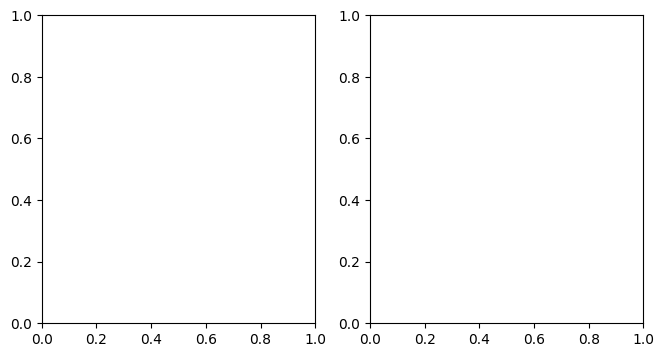

In [ ]:
import matplotlib.pyplot as plt

img1, label1 = train_dataset[0]
img2, label2 = train_dataset[0]
img3, label3 = train_dataset[0]

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(img1.permute(1,2,0))
plt.title("Augmented Image 1")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(img2.permute(1,2,0))
plt.title("Augmented Image 2")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(img3.permute(1,2,0))
plt.title("Augmented Image 3")
plt.axis("off")

plt.show()


## 8. Apply different transforms to split datasets
*random_split gives subsets, so we wrap them to apply transforms properly.*

In [ ]:
class CustomSubset(torch.utils.data.Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        image, label = self.subset[idx]
        if self.transform:
            image = self.transform(image)
        return image, label   

In [ ]:
train_dataset = CustomSubset(train_dataset, transform=train_transform)
val_dataset = CustomSubset(val_dataset, transform=test_transform)
test_dataset = CustomSubset(test_dataset, transform=test_transform)

In [ ]:
train_dataset

## 9. Handle imbalance with weighted sampler
*This is important because your classes are imbalanced.*

In [ ]:
# labels from original split indices
train_indices = train_dataset.subset.indices
train_labels = [full_dataset.samples[i][1] for i in train_indices]

class_count = np.bincount(train_labels)
print("Class counts in train split:", class_count)

class_weights = 1. / class_count
sample_weights = [class_weights[label] for label in train_labels]

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

Class counts in train split: [ 88  32  17  23 120  12 628]


## 10. Create DataLoaders

In [ ]:
batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, sampler=sampler)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [ ]:
images, labels = next(iter(train_loader))
print("Image batch shape:", images.shape)   # [batch_size, 3, 224, 224]
print("Label batch shape:", labels.shape)   # [batch_size]

Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])


## 11. Load pretrained ResNet50, freeze all layers, change classifier

In [ ]:
import torchvision.models as models
import torch.nn as nn

import torchvision.models as models
resnet50 = models.resnet50(pretrained=True)
print(resnet50)


/Users/abroadhub/Library/Python/3.9/lib/python/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/abroadhub/Library/Python/3.9/lib/python/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [ ]:
resnet50.fc.in_features

2048

In [ ]:
resnet50.fc.out_features

1000

In [ ]:
# Freezing all layers
for param in resnet50.parameters():
    param.requires_grad = False

In [ ]:

# Unfreeze only the new FC layer
for param in resnet50.fc.parameters():
    param.requires_grad = True

In [ ]:
# replace fc (final layer)
resnet50.fc = nn.Linear(resnet50.fc.in_features, 7)
for param in resnet50.fc.parameters():
    param.requires_grad = True

In [ ]:
resnet50 = resnet50.to(device)

In [ ]:
learning_rate = 0.0001
epochs = 10
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(resnet50.fc.parameters(), lr=learning_rate)

# training loop
for epoch in range(epochs):

  total_epoch_loss = 0

  for batch_features, batch_labels in train_loader:

    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

    outputs = resnet50(batch_features)

    loss = criterion(outputs, batch_labels)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    total_epoch_loss = total_epoch_loss + loss.item()

  avg_loss = total_epoch_loss/len(train_loader)
  print(f'Epoch: {epoch + 1} , Loss: {avg_loss}')

Epoch: 1 , Loss: 3.207972658091578
Epoch: 2 , Loss: 3.382593812613652
Epoch: 3 , Loss: 3.5306000175147223
Epoch: 4 , Loss: 3.033735092343955
Epoch: 5 , Loss: 3.2376111622514396
Epoch: 6 , Loss: 3.2668044649321457
Epoch: 7 , Loss: 3.091771331326715
Epoch: 8 , Loss: 2.9588206533727974
Epoch: 9 , Loss: 3.408632520971627
Epoch: 10 , Loss: 2.9459314592953385


In [ ]:
# evaluate the TEST data
total = 0
correct = 0
with torch.no_grad():

  for batch_features, batch_labels in test_loader:

    # move data to gpu
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

    outputs = resnet50(batch_features)

    _, predicted = torch.max(outputs, 1)

    total = total + batch_labels.shape[0]

    correct = correct + (predicted == batch_labels).sum().item()

print(correct/total)

0.3686868686868687


In [ ]:
resnet18 = models.resnet18(pretrained=True)

# freeze all layers
for param in resnet18.parameters():
    param.requires_grad = False

# replace final layer
num_classes = len(full_dataset.classes)
resnet18.fc = nn.Linear(resnet18.fc.in_features, num_classes)

# make fc trainable
for param in resnet18.fc.parameters():
    param.requires_grad = True

resnet18 = resnet18.to(device)

/Users/abroadhub/Library/Python/3.9/lib/python/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [ ]:
learning_rate = 0.0001
epochs = 10
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(resnet18.fc.parameters(), lr=learning_rate)

# training loop
for epoch in range(epochs):

  total_epoch_loss = 0

  for batch_features, batch_labels in train_loader:

    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

    outputs = resnet18(batch_features)

    loss = criterion(outputs, batch_labels)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    total_epoch_loss = total_epoch_loss + loss.item()

  avg_loss = total_epoch_loss/len(train_loader)
  print(f'Epoch: {epoch + 1} , Loss: {avg_loss}')

Epoch: 1 , Loss: 1.9910813857769143
Epoch: 2 , Loss: 1.9636553567031334
Epoch: 3 , Loss: 1.8959917117809426
Epoch: 4 , Loss: 1.8666419900696853
Epoch: 5 , Loss: 1.8502676569182297
Epoch: 6 , Loss: 1.8033446320172013
Epoch: 7 , Loss: 1.7671403556034482
Epoch: 8 , Loss: 1.7389349403052494
Epoch: 9 , Loss: 1.695896868048043
Epoch: 10 , Loss: 1.6978741514271702


In [ ]:
# evaluate the TEST data
total = 0
correct = 0
with torch.no_grad():

  for batch_features, batch_labels in test_loader:

    # move data to gpu
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

    outputs = resnet18(batch_features)

    _, predicted = torch.max(outputs, 1)

    total = total + batch_labels.shape[0]

    correct = correct + (predicted == batch_labels).sum().item()

print(correct/total)

0.20202020202020202


In [ ]:
efficientnet = models.efficientnet_b0(pretrained=True)

for param in efficientnet.parameters():
    param.requires_grad = False

num_classes = len(full_dataset.classes)
efficientnet.classifier[1] = nn.Linear(efficientnet.classifier[1].in_features, num_classes)

for param in efficientnet.classifier.parameters():
    param.requires_grad = True

efficientnet = efficientnet.to(device)

/Users/abroadhub/Library/Python/3.9/lib/python/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [ ]:
import torchvision.models as models
import torch.nn as nn

efficientnet = models.efficientnet_b0(pretrained=True)

# freeze all first
for param in efficientnet.parameters():
    param.requires_grad = False

# replace classifier
num_classes = len(full_dataset.classes)
efficientnet.classifier[1] = nn.Linear(efficientnet.classifier[1].in_features, num_classes)

# train classifier
for param in efficientnet.classifier.parameters():
    param.requires_grad = True

# also unfreeze last feature block
for param in efficientnet.features[-1].parameters():
    param.requires_grad = True

efficientnet = efficientnet.to(device)


In [ ]:
learning_rate = 0.0001
epochs = 15
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(efficientnet.classifier.parameters(), lr=learning_rate)

# training loop
for epoch in range(epochs):

  total_epoch_loss = 0

  for batch_features, batch_labels in train_loader:

    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

    outputs = efficientnet(batch_features)

    loss = criterion(outputs, batch_labels)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    total_epoch_loss = total_epoch_loss + loss.item()

  avg_loss = total_epoch_loss/len(train_loader)
  print(f'Epoch: {epoch + 1} , Loss: {avg_loss}')

KeyboardInterrupt: 

In [ ]:
# evaluate the TEST data
total = 0
correct = 0
with torch.no_grad():

  for batch_features, batch_labels in test_loader:

    # move data to gpu
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

    outputs = efficientnet(batch_features)

    _, predicted = torch.max(outputs, 1)

    total = total + batch_labels.shape[0]

    correct = correct + (predicted == batch_labels).sum().item()

print(correct/total)

0.09090909090909091
